In [1]:
import sys
import csv
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from datetime import datetime

In [2]:
def load_trajectory_data(filename):
    """Завантажує дані з CSV файлу"""
    data = []
    try:
        with open(filename, 'r') as csvfile:
            reader = csv.reader(csvfile)
            header = next(reader)  # Пропускаємо заголовок
            for row in reader:
                # time, target_x, target_y, gaze_x, gaze_y, filtered_x, filtered_y
                time_val = float(row[0])
                target_x = int(row[1])
                target_y = int(row[2])
                gaze_x = int(row[3]) if row[3] != 'None' else None
                gaze_y = int(row[4]) if row[4] != 'None' else None
                filtered_x = int(row[5]) if row[5] != 'None' else None
                filtered_y = int(row[6]) if row[6] != 'None' else None
                
                data.append((time_val, target_x, target_y, gaze_x, gaze_y, filtered_x, filtered_y))
    except Exception as e:
        print(f"❌ Помилка завантаження файлу {filename}: {e}")
        return None
    
    return data

In [3]:
def calculate_statistics(data):
    """Обчислює статистику для даних"""
    if not data:
        return None
    
    errors_raw = []
    errors_filtered = []
    
    for time_val, tx, ty, gx, gy, fx, fy in data:
        if gx is not None and fx is not None:
            error_raw = math.sqrt((tx - gx)**2 + (ty - gy)**2)
            error_filtered = math.sqrt((tx - fx)**2 + (ty - fy)**2)
            errors_raw.append(error_raw)
            errors_filtered.append(error_filtered)
    
    if not errors_raw or not errors_filtered:
        return None
    
    stats = {
        'avg_error_raw': np.mean(errors_raw),
        'avg_error_filtered': np.mean(errors_filtered),
        'std_error_raw': np.std(errors_raw),
        'std_error_filtered': np.std(errors_filtered),
        'var_raw': np.var(errors_raw),
        'var_filtered': np.var(errors_filtered),
        'total_points': len(data),
        'valid_points': len(errors_raw)
    }
    
    # Обчислюємо ефект згладжування
    if stats['var_raw'] > 0:
        stats['smoothing_effect'] = ((stats['var_raw'] - stats['var_filtered']) / stats['var_raw']) * 100
    else:
        stats['smoothing_effect'] = 0
    
    return stats

In [47]:
def plot_trajectory_analysis(data, filename=None):
    """Створює детальний графік аналізу траєкторії"""
    if not data:
        print("❌ Немає даних для відображення")
        return

    import matplotlib.pyplot as plt
    import math

    # Розпаковуємо дані
    times = [d[0] for d in data]
    target_x = [d[1] for d in data]
    target_y = [d[2] for d in data]
    gaze_x = [d[3] for d in data]
    gaze_y = [d[4] for d in data]
    filtered_x = [d[5] for d in data]
    filtered_y = [d[6] for d in data]

    # Кольорова палітра
    colors = {
        'target': '#FF6B6B',      # Рожево-червоний
        'raw': '#FFB347',         # Теплий помаранчевий
        'filtered': '#4ECDC4',    # М'ятно-зелений
        'background': '#FFFFFF',  # Білий фон
        'grid': '#E8E8E8',        # Світло-сірий для сітки
        'text': '#2C3E50'         # Темно-сірий для тексту
    }

    # 1. Траєкторія в просторі
    plt.figure(figsize=(12, 8))
    plt.style.use('default')
    plt.gca().set_facecolor(colors['background'])
    plt.grid(True, alpha=0.3, color=colors['grid'])

    plt.plot(target_x[:-1], target_y[:-1], color=colors['target'], linewidth=4, 
             label='Цільова точка', alpha=0.9, zorder=3, solid_capstyle='round')
    plt.scatter(gaze_x, gaze_y, c=colors['raw'], s=12, alpha=0.6, 
                label='Сирі координати', edgecolors='white', linewidth=0.5, zorder=2)
    plt.scatter(filtered_x, filtered_y, c=colors['filtered'], s=15, alpha=0.8, 
                label='Фільтр Калмана', edgecolors='white', linewidth=0.5, zorder=4)

    plt.xlabel('X координата (пікселі)', color=colors['text'], fontweight='bold')
    plt.ylabel('Y координата (пікселі)', color=colors['text'], fontweight='bold')
    title = 'Траєкторія руху погляду'
    if filename:
        title += f' - {filename}'
    plt.title(title, color=colors['text'], fontweight='bold', pad=20)

    legend = plt.legend(frameon=True, fancybox=True, shadow=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    plt.gca().set_aspect('equal')
    plt.tight_layout()
    plt.show()

    # 2. X координата в часі
    plt.figure(figsize=(12, 6))
    plt.gca().set_facecolor(colors['background'])
    plt.grid(True, alpha=0.3, color=colors['grid'])

    plt.plot(times, target_x, color=colors['target'], linewidth=3, label='X цілі', alpha=0.9)
    plt.plot(times, gaze_x, color=colors['raw'], alpha=0.7, linewidth=2, label='X сирі')
    plt.plot(times, filtered_x, color=colors['filtered'], alpha=0.9, linewidth=2.5, label='X фільтр Калман')

    plt.xlabel('Час (с)', color=colors['text'], fontweight='bold')
    plt.ylabel('X координата (пікселі)', color=colors['text'], fontweight='bold')
    plt.title('X координата в часі', color=colors['text'], fontweight='bold', pad=20)

    legend = plt.legend(frameon=True, fancybox=True, shadow=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    plt.tight_layout()
    plt.show()

    # 3. Y координата в часі
    plt.figure(figsize=(12, 6))
    plt.gca().set_facecolor(colors['background'])
    plt.grid(True, alpha=0.3, color=colors['grid'])

    plt.plot(times, target_y, color=colors['target'], linewidth=3, label='Y цілі', alpha=0.9)
    plt.plot(times, gaze_y, color=colors['raw'], alpha=0.7, linewidth=2, label='Y сирі')
    plt.plot(times, filtered_y, color=colors['filtered'], alpha=0.9, linewidth=2.5, label='Y фільтр Калмана')

    plt.xlabel('Час (с)', color=colors['text'], fontweight='bold')
    plt.ylabel('Y координата (пікселі)', color=colors['text'], fontweight='bold')
    plt.title('Y координата в часі', color=colors['text'], fontweight='bold', pad=20)

    legend = plt.legend(frameon=True, fancybox=True, shadow=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    plt.tight_layout()
    plt.show()

    # 4. Помилки в часі
    errors_raw = []
    errors_filtered = []
    for i in range(len(times)):
        if gaze_x[i] is not None and filtered_x[i] is not None:
            error_raw = math.sqrt((target_x[i] - gaze_x[i])**2 + (target_y[i] - gaze_y[i])**2)
            error_filtered = math.sqrt((target_x[i] - filtered_x[i])**2 + (target_y[i] - filtered_y[i])**2)
            errors_raw.append(error_raw)
            errors_filtered.append(error_filtered)
        else:
            errors_raw.append(None)
            errors_filtered.append(None)

    valid_indices = [i for i, (er, ef) in enumerate(zip(errors_raw, errors_filtered)) 
                     if er is not None and ef is not None]
    valid_times = [times[i] for i in valid_indices]
    valid_errors_raw = [errors_raw[i] for i in valid_indices]
    valid_errors_filtered = [errors_filtered[i] for i in valid_indices]

    plt.figure(figsize=(12, 6))
    plt.gca().set_facecolor(colors['background'])
    plt.grid(True, alpha=0.3, color=colors['grid'])

    plt.plot(valid_times, valid_errors_raw, color=colors['raw'], alpha=0.7, linewidth=2, label='Сира помилка')
    plt.plot(valid_times, valid_errors_filtered, color=colors['filtered'], alpha=0.9, linewidth=2.5, label='Помилка після фільтра')

    plt.xlabel('Час (с)', color=colors['text'], fontweight='bold')
    plt.ylabel('Похибка (пікселі)', color=colors['text'], fontweight='bold')
    plt.title('Похибка в часі', color=colors['text'], fontweight='bold', pad=20)

    legend = plt.legend(frameon=True, fancybox=True, shadow=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)

    if valid_errors_raw and valid_errors_filtered:
        stats = calculate_statistics(data)
        if stats:
            stats_text = (f'Середня похибка:\n'
                          f'Сирі: {stats["avg_error_raw"]:.1f}px\n'
                          f'Фільтр Калмана: {stats["avg_error_filtered"]:.1f}px\n'
                          f'Згладжено: {stats["smoothing_effect"]:.1f}%')

            bbox_props = dict(boxstyle='round,pad=0.5', facecolor='white', 
                              edgecolor=colors['filtered'], linewidth=2, alpha=0.95)
            plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
                     verticalalignment='top', bbox=bbox_props, 
                     fontsize=10, color=colors['text'], fontweight='bold')

    plt.tight_layout()
    plt.show()


In [5]:
def print_statistics(data, filename=None):
    """Виводить детальну статистику"""
    stats = calculate_statistics(data)
    if not stats:
        print("❌ Неможливо обчислити статистику")
        return
    
    print("\n" + "="*60)
    if filename:
        print(f"📊 СТАТИСТИКА ДЛЯ ФАЙЛУ: {filename}")
    else:
        print("📊 СТАТИСТИКА ТРАЄКТОРІЇ")
    print("="*60)
    print(f"📈 Загальна кількість точок:     {stats['total_points']}")
    print(f"📈 Валідних точок:               {stats['valid_points']}")
    print(f"📈 Середня помилка (Raw):        {stats['avg_error_raw']:.2f}px")
    print(f"📈 Середня помилка (Kalman):     {stats['avg_error_filtered']:.2f}px")
    print(f"📈 Стандартне відхилення (Raw):  {stats['std_error_raw']:.2f}px")
    print(f"📈 Стандартне відхилення (Kalman): {stats['std_error_filtered']:.2f}px")
    print(f"📈 Дисперсія (Raw):              {stats['var_raw']:.2f}")
    print(f"📈 Дисперсія (Kalman):           {stats['var_filtered']:.2f}")
    print(f"📈 Ефект згладжування:          {stats['smoothing_effect']:.1f}%")
    print("="*60)
    
    # Покращення точності
    improvement = ((stats['avg_error_raw'] - stats['avg_error_filtered']) / stats['avg_error_raw']) * 100
    print(f"🎯 Покращення точності: {improvement:.1f}%")
    
    # Зменшення шуму
    noise_reduction = ((stats['std_error_raw'] - stats['std_error_filtered']) / stats['std_error_raw']) * 100
    print(f"🔇 Зменшення шуму: {noise_reduction:.1f}%")



In [6]:
def find_latest_trajectory_file():
    """Знаходить найновіший файл з результатами траєкторії"""
    pattern = "trajectory_test_*.csv"
    files = glob.glob(pattern)
    
    if not files:
        return None
    
    # Сортуємо за часом модифікації
    files.sort(key=lambda x: Path(x).stat().st_mtime, reverse=True)
    return files[0]

In [7]:
def list_trajectory_files():
    """Показує список всіх файлів з результатами траєкторії"""
    pattern = "trajectory_test_*.csv"
    files = glob.glob(pattern)
    
    if not files:
        print("❌ Файли з результатами траєкторії не знайдено")
        return []
    
    print("📁 Знайдені файли з результатами:")
    for i, file in enumerate(files, 1):
        file_path = Path(file)
        mod_time = datetime.fromtimestamp(file_path.stat().st_mtime)
        size = file_path.stat().st_size
        print(f"{i}. {file} ({size} bytes, {mod_time.strftime('%Y-%m-%d %H:%M:%S')})")
    
    return files

In [8]:
if len(sys.argv) > 1:
    filename = "trajectory_test_1748641191.csv"
    if not Path(filename).exists():
        print(f"❌ Файл {filename} не знайдено")

❌ Файл trajectory_test_1748641191.csv не знайдено


In [21]:
files = list_trajectory_files()

📁 Знайдені файли з результатами:
1. trajectory_test_1750019713.csv (26628 bytes, 2025-06-15 23:35:13)
2. trajectory_test_1750019459.csv (26447 bytes, 2025-06-15 23:30:59)


In [22]:
choice = input("Ваш вибір (0-{}): ".format(len(files))).strip()

In [23]:
if choice == "0" or choice == "":
    filename = find_latest_trajectory_file()
    if not filename:
        print("❌ Не знайдено файлів для аналізу")
else:
    choice_idx = int(choice) - 1
    if 0 <= choice_idx < len(files):
        filename = files[choice_idx]
    else:
        print("❌ Невірний вибір")
print(f"\n🔍 Аналізуємо файл: {filename}")


🔍 Аналізуємо файл: trajectory_test_1750019713.csv


In [24]:
data = load_trajectory_data(filename)
print(f"✅ Завантажено {len(data)} точок даних")

✅ Завантажено 601 точок даних


In [25]:
print_statistics(data, filename)


📊 СТАТИСТИКА ДЛЯ ФАЙЛУ: trajectory_test_1750019713.csv
📈 Загальна кількість точок:     601
📈 Валідних точок:               601
📈 Середня помилка (Raw):        66.10px
📈 Середня помилка (Kalman):     59.23px
📈 Стандартне відхилення (Raw):  40.73px
📈 Стандартне відхилення (Kalman): 34.76px
📈 Дисперсія (Raw):              1658.63
📈 Дисперсія (Kalman):           1208.29
📈 Ефект згладжування:          27.2%
🎯 Покращення точності: 10.4%
🔇 Зменшення шуму: 14.6%


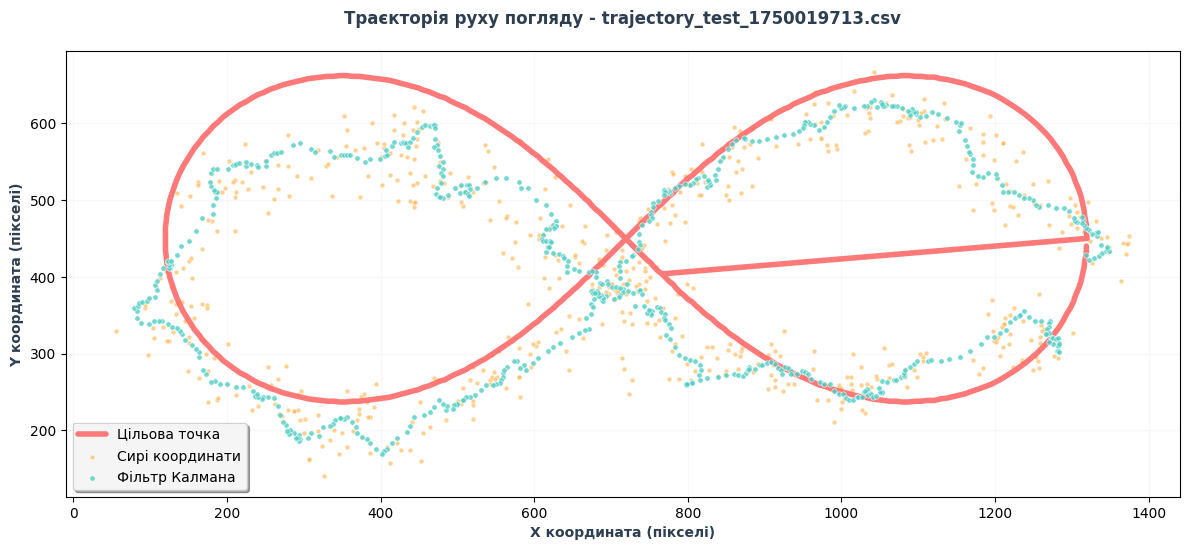

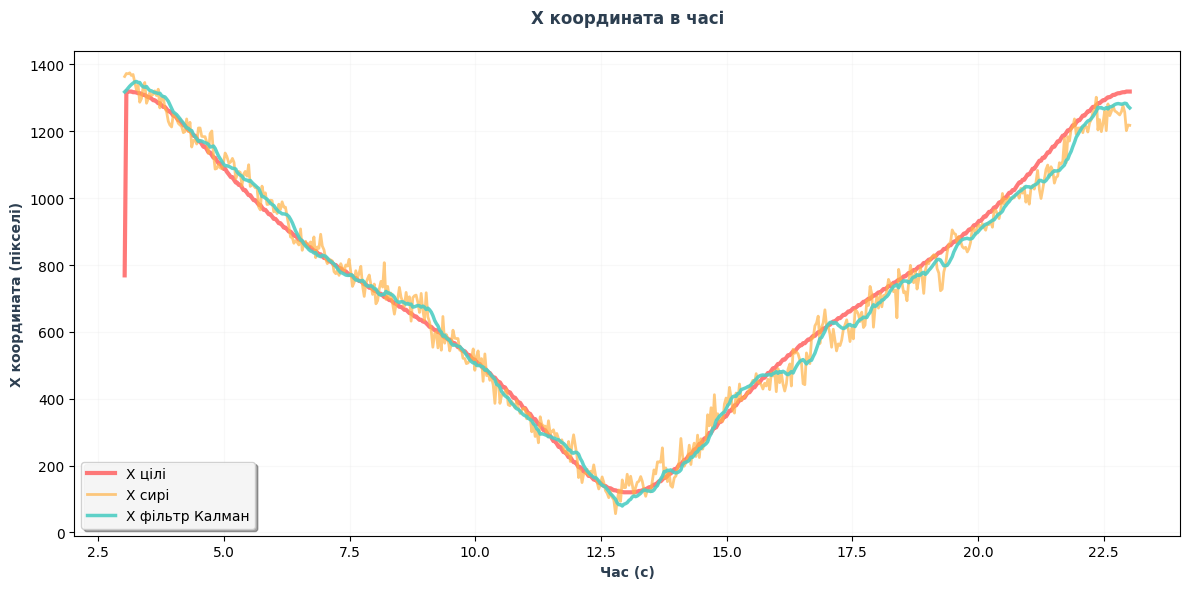

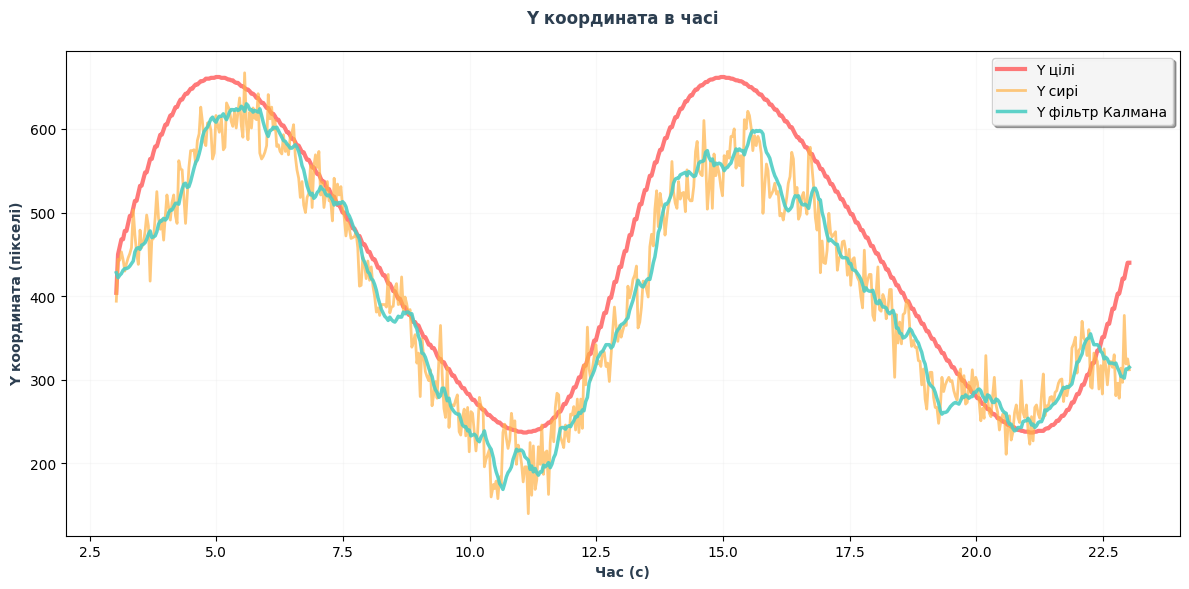

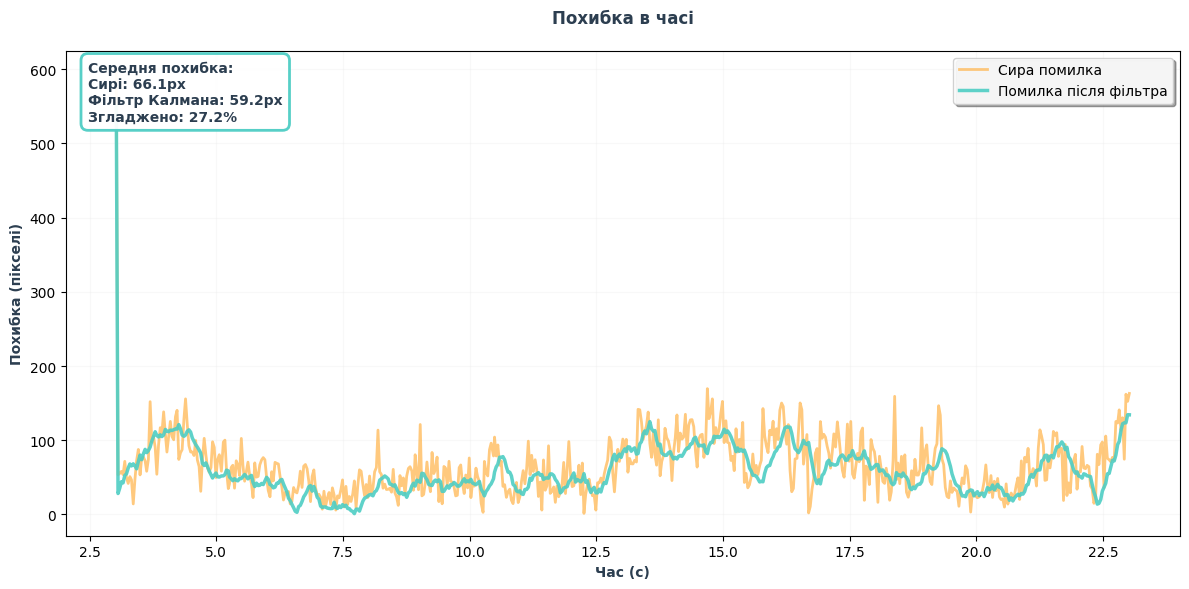

In [48]:
plot_trajectory_analysis(data, filename)

In [27]:
def calculate_angular_error(target_x, target_y, gaze_x, gaze_y, screen_width, screen_height, 
                          viewing_distance_cm=60, screen_width_cm=34, screen_height_cm=19):
    """
    Calculate angular error in degrees between target and gaze points
    
    Args:
        target_x, target_y: Target coordinates in pixels
        gaze_x, gaze_y: Gaze coordinates in pixels
        screen_width, screen_height: Screen resolution in pixels
        viewing_distance_cm: Distance from user to screen in cm
        screen_width_cm, screen_height_cm: Physical screen dimensions in cm
    
    Returns:
        Angular error in degrees
    """
    import math
    
    # Convert pixel coordinates to physical coordinates (cm)
    cm_per_pixel_x = screen_width_cm / screen_width
    cm_per_pixel_y = screen_height_cm / screen_height
    
    # Convert to cm relative to screen center
    target_x_cm = (target_x - screen_width/2) * cm_per_pixel_x
    target_y_cm = (target_y - screen_height/2) * cm_per_pixel_y
    gaze_x_cm = (gaze_x - screen_width/2) * cm_per_pixel_x
    gaze_y_cm = (gaze_y - screen_height/2) * cm_per_pixel_y
    
    # Calculate 3D vectors from eye to target and gaze points
    # Eye is at (0, 0, -viewing_distance_cm)
    target_vector = [target_x_cm, target_y_cm, viewing_distance_cm]
    gaze_vector = [gaze_x_cm, gaze_y_cm, viewing_distance_cm]
    
    # Calculate magnitudes
    target_mag = math.sqrt(sum(x**2 for x in target_vector))
    gaze_mag = math.sqrt(sum(x**2 for x in gaze_vector))
    
    # Calculate dot product
    dot_product = sum(t*g for t, g in zip(target_vector, gaze_vector))
    
    # Calculate angle using dot product formula
    cos_angle = dot_product / (target_mag * gaze_mag)
    
    # Clamp to valid range for acos
    cos_angle = max(-1, min(1, cos_angle))
    
    # Convert to degrees
    angular_error_degrees = math.degrees(math.acos(cos_angle))
    
    return angular_error_degrees




In [28]:
def calculate_angular_error(target_x, target_y, gaze_x, gaze_y, screen_width, screen_height, 
                          viewing_distance_cm=60, screen_width_cm=34, screen_height_cm=19):
    """
    Calculate angular error in degrees between target and gaze points
    
    Args:
        target_x, target_y: Target coordinates in pixels
        gaze_x, gaze_y: Gaze coordinates in pixels
        screen_width, screen_height: Screen resolution in pixels
        viewing_distance_cm: Distance from user to screen in cm
        screen_width_cm, screen_height_cm: Physical screen dimensions in cm
    
    Returns:
        Angular error in degrees
    """
    import math
    
    # Convert pixel coordinates to physical coordinates (cm)
    cm_per_pixel_x = screen_width_cm / screen_width
    cm_per_pixel_y = screen_height_cm / screen_height
    
    # Convert to cm relative to screen center
    target_x_cm = (target_x - screen_width/2) * cm_per_pixel_x
    target_y_cm = (target_y - screen_height/2) * cm_per_pixel_y
    gaze_x_cm = (gaze_x - screen_width/2) * cm_per_pixel_x
    gaze_y_cm = (gaze_y - screen_height/2) * cm_per_pixel_y
    
    # Calculate 3D vectors from eye to target and gaze points
    # Eye is at (0, 0, -viewing_distance_cm)
    target_vector = [target_x_cm, target_y_cm, viewing_distance_cm]
    gaze_vector = [gaze_x_cm, gaze_y_cm, viewing_distance_cm]
    
    # Calculate magnitudes
    target_mag = math.sqrt(sum(x**2 for x in target_vector))
    gaze_mag = math.sqrt(sum(x**2 for x in gaze_vector))
    
    # Calculate dot product
    dot_product = sum(t*g for t, g in zip(target_vector, gaze_vector))
    
    # Calculate angle using dot product formula
    cos_angle = dot_product / (target_mag * gaze_mag)
    
    # Clamp to valid range for acos
    cos_angle = max(-1, min(1, cos_angle))
    
    # Convert to degrees
    angular_error_degrees = math.degrees(math.acos(cos_angle))
    
    return angular_error_degrees




In [29]:
# To integrate into your trajectory_analysis.py, modify the calculate_statistics function:
def calculate_statistics(data):
    """Обчислює статистику для даних включаючи кутову помилку"""
    if not data:
        return None
    
    # Assume standard monitor setup - adjust these values for your setup
    SCREEN_WIDTH = 2560  # pixels
    SCREEN_HEIGHT = 1600  # pixels
    VIEWING_DISTANCE_CM = 60  # cm
    SCREEN_WIDTH_CM = 30.41  # cm (typical 15.6" laptop)
    SCREEN_HEIGHT_CM = 21.24  # cm
    
    errors_raw = []
    errors_filtered = []
    angular_errors_raw = []
    angular_errors_filtered = []
    
    for time_val, tx, ty, gx, gy, fx, fy in data:
        if gx is not None and fx is not None:
            # Pixel errors
            error_raw = math.sqrt((tx - gx)**2 + (ty - gy)**2)
            error_filtered = math.sqrt((tx - fx)**2 + (ty - fy)**2)
            errors_raw.append(error_raw)
            errors_filtered.append(error_filtered)
            
            # Angular errors
            angular_error_raw = calculate_angular_error(
                tx, ty, gx, gy, SCREEN_WIDTH, SCREEN_HEIGHT,
                VIEWING_DISTANCE_CM, SCREEN_WIDTH_CM, SCREEN_HEIGHT_CM
            )
            angular_error_filtered = calculate_angular_error(
                tx, ty, fx, fy, SCREEN_WIDTH, SCREEN_HEIGHT,
                VIEWING_DISTANCE_CM, SCREEN_WIDTH_CM, SCREEN_HEIGHT_CM
            )
            angular_errors_raw.append(angular_error_raw)
            angular_errors_filtered.append(angular_error_filtered)
    
    if not errors_raw:
        return None
    
    stats = {
        # Pixel errors
        'avg_error_raw': np.mean(errors_raw),
        'avg_error_filtered': np.mean(errors_filtered),
        'std_error_raw': np.std(errors_raw),
        'std_error_filtered': np.std(errors_filtered),
        'var_raw': np.var(errors_raw),
        'var_filtered': np.var(errors_filtered),
        
        # Angular errors (degrees)
        'avg_angular_error_raw': np.mean(angular_errors_raw),
        'avg_angular_error_filtered': np.mean(angular_errors_filtered),
        'std_angular_error_raw': np.std(angular_errors_raw),
        'std_angular_error_filtered': np.std(angular_errors_filtered),
        
        'total_points': len(data),
        'valid_points': len(errors_raw)
    }
    
    # Smoothing effect
    if stats['var_raw'] > 0:
        stats['smoothing_effect'] = ((stats['var_raw'] - stats['var_filtered']) / stats['var_raw']) * 100
    else:
        stats['smoothing_effect'] = 0
    
    return stats

In [30]:
# Example usage in your statistics calculation:
def calculate_statistics_with_angular_error(data, screen_width, screen_height):
    """Enhanced statistics with angular error"""
    if not data:
        return None
    
    errors_raw = []
    errors_filtered = []
    angular_errors_raw = []
    angular_errors_filtered = []
    
    for time_val, tx, ty, gx, gy, fx, fy in data:
        if gx is not None and fx is not None:
            # Euclidean error (pixels)
            error_raw = math.sqrt((tx - gx)**2 + (ty - gy)**2)
            error_filtered = math.sqrt((tx - fx)**2 + (ty - fy)**2)
            errors_raw.append(error_raw)
            errors_filtered.append(error_filtered)
            
            # Angular error (degrees)
            angular_error_raw = calculate_angular_error(tx, ty, gx, gy, screen_width, screen_height)
            angular_error_filtered = calculate_angular_error(tx, ty, fx, fy, screen_width, screen_height)
            angular_errors_raw.append(angular_error_raw)
            angular_errors_filtered.append(angular_error_filtered)
    
    if not errors_raw:
        return None
    
    stats = {
        # Pixel errors
        'avg_error_raw_px': np.mean(errors_raw),
        'avg_error_filtered_px': np.mean(errors_filtered),
        'std_error_raw_px': np.std(errors_raw),
        'std_error_filtered_px': np.std(errors_filtered),
        
        # Angular errors
        'avg_error_raw_deg': np.mean(angular_errors_raw),
        'avg_error_filtered_deg': np.mean(angular_errors_filtered),
        'std_error_raw_deg': np.std(angular_errors_raw),
        'std_error_filtered_deg': np.std(angular_errors_filtered),
        
        'total_points': len(data),
        'valid_points': len(errors_raw)
    }
    
    return stats




In [31]:
def evaluate_angular_error_quality(avg_angular_error_deg):
    """
    Evaluate the quality of gaze tracking based on angular error
    
    Returns quality rating and description
    """
    if avg_angular_error_deg < 0.5:
        return "Excellent", "Research-grade accuracy"
    elif avg_angular_error_deg < 1.0:
        return "Very Good", "Commercial eye tracker quality"
    elif avg_angular_error_deg < 2.0:
        return "Good", "Acceptable for most applications"
    elif avg_angular_error_deg < 3.0:
        return "Fair", "Usable but needs improvement"
    elif avg_angular_error_deg < 5.0:
        return "Poor", "Limited usability"
    else:
        return "Very Poor", "Not suitable for applications"

def print_angular_error_analysis(stats):
    """Print detailed angular error analysis"""
    print("\n" + "="*60)
    print("🎯 ANGULAR ERROR ANALYSIS")
    print("="*60)
    
    # Raw gaze analysis
    raw_quality, raw_desc = evaluate_angular_error_quality(stats['avg_angular_error_raw'])
    print(f"📊 Raw Gaze:")
    print(f"   Average: {stats['avg_angular_error_raw']:.2f}° ({raw_quality})")
    print(f"   Std Dev: {stats['std_angular_error_raw']:.2f}°")
    print(f"   Quality: {raw_desc}")
    
    # Filtered gaze analysis
    filtered_quality, filtered_desc = evaluate_angular_error_quality(stats['avg_angular_error_filtered'])
    print(f"\n📊 Kalman Filtered:")
    print(f"   Average: {stats['avg_angular_error_filtered']:.2f}° ({filtered_quality})")
    print(f"   Std Dev: {stats['std_angular_error_filtered']:.2f}°")
    print(f"   Quality: {filtered_desc}")
    
    # Improvement analysis
    angular_improvement = ((stats['avg_angular_error_raw'] - stats['avg_angular_error_filtered']) / 
                          stats['avg_angular_error_raw']) * 100
    precision_improvement = ((stats['std_angular_error_raw'] - stats['std_angular_error_filtered']) / 
                           stats['std_angular_error_raw']) * 100
    
    print(f"\n🎯 Filter Performance:")
    print(f"   Accuracy improvement: {angular_improvement:.1f}%")
    print(f"   Precision improvement: {precision_improvement:.1f}%")
    
    # Benchmarks
    print(f"\n📏 Industry Benchmarks:")
    print(f"   Research grade: < 0.5°")
    print(f"   Commercial grade: 0.5-1.0°")
    print(f"   Consumer grade: 1.0-2.0°")
    print(f"   Minimum usable: < 3.0°")
    print("="*60)

In [37]:
def plot_angular_error_analysis(data, filename=None):
    """Plot angular error analysis with multiple visualizations"""
    if not data:
        print("❌ No data to display")
        return
    
    # Calculate angular errors for all data points
    times = [d[0] for d in data]
    target_x = [d[1] for d in data]
    target_y = [d[2] for d in data]
    gaze_x = [d[3] for d in data]
    gaze_y = [d[4] for d in data]
    filtered_x = [d[5] for d in data]
    filtered_y = [d[6] for d in data]
    
    # Screen parameters - adjust for your setup
    SCREEN_WIDTH = 1920
    SCREEN_HEIGHT = 1080
    VIEWING_DISTANCE_CM = 60
    SCREEN_WIDTH_CM = 34
    SCREEN_HEIGHT_CM = 19
    
    angular_errors_raw = []
    angular_errors_filtered = []
    valid_times = []
    
    for i in range(len(times)):
        if gaze_x[i] is not None and filtered_x[i] is not None:
            angular_raw = calculate_angular_error(
                target_x[i], target_y[i], gaze_x[i], gaze_y[i],
                SCREEN_WIDTH, SCREEN_HEIGHT, VIEWING_DISTANCE_CM, 
                SCREEN_WIDTH_CM, SCREEN_HEIGHT_CM
            )
            angular_filtered = calculate_angular_error(
                target_x[i], target_y[i], filtered_x[i], filtered_y[i],
                SCREEN_WIDTH, SCREEN_HEIGHT, VIEWING_DISTANCE_CM, 
                SCREEN_WIDTH_CM, SCREEN_HEIGHT_CM
            )
            
            angular_errors_raw.append(angular_raw)
            angular_errors_filtered.append(angular_filtered)
            valid_times.append(times[i])
    
    colors = {
        'raw': '#FFB347',
        'filtered': '#4ECDC4',
        'excellent': '#2ECC71',
        'good': '#F39C12',
        'poor': '#E74C3C',
        'background': '#FFFFFF',
        'grid': '#E8E8E8',
        'text': '#2C3E50'
    }
    
    # 1. Angular Error Over Time
    plt.figure(figsize=(14, 8))
    plt.gca().set_facecolor(colors['background'])
    plt.grid(True, alpha=0.3, color=colors['grid'])
    
    plt.plot(valid_times, angular_errors_raw, color=colors['raw'], alpha=0.7, 
             linewidth=2, label='Сира кутова похибка')
    plt.plot(valid_times, angular_errors_filtered, color=colors['filtered'], 
             alpha=0.9, linewidth=2.5, label='Кутова похибка після фільтрації Калмана')
    
    # Add quality threshold lines
    plt.axhline(y=0.5, color=colors['excellent'], linestyle='--', alpha=0.7, 
                label='Відмінна точність (< 0.5°)')
    plt.axhline(y=1.0, color=colors['good'], linestyle='--', alpha=0.7, 
                label='Дуже добра точність (< 1.0°)')
    plt.axhline(y=2.0, color=colors['poor'], linestyle='--', alpha=0.7, 
                label='Прийнятна точність (< 2.0°)')
    
    plt.xlabel('Час (с)', fontweight='bold', color=colors['text'])
    plt.ylabel('Кутова похибка (градуси)', fontweight='bold', color=colors['text'])
    plt.title('Кутова похибка у часі', fontweight='bold', color=colors['text'], pad=20)
    plt.legend(frameon=True, fancybox=True, shadow=True)
    plt.tight_layout()
    plt.show()
    
    # 2. Angular Error Distribution (Histogram)
    plt.figure(figsize=(12, 6))
    plt.gca().set_facecolor(colors['background'])
    plt.grid(True, alpha=0.3, color=colors['grid'])
    
    plt.hist(angular_errors_raw, bins=30, alpha=0.6, color=colors['raw'], 
             label='Сира кутова похибка', density=True)
    plt.hist(angular_errors_filtered, bins=30, alpha=0.8, color=colors['filtered'], 
             label='Кутова похибка після фільтрації Калмана', density=True)
    
    # Add quality threshold lines
    plt.axvline(x=0.5, color=colors['excellent'], linestyle='--', alpha=0.7, 
                label='Відмінна точність (< 0.5°)')
    plt.axvline(x=1.0, color=colors['good'], linestyle='--', alpha=0.7, 
                label='Дуже добра точність (< 1.0°)')
    plt.axvline(x=2.0, color=colors['poor'], linestyle='--', alpha=0.7, 
                label='Прийнятна точність (< 2.0°)')
    
    plt.xlabel('Кутова похибка (градуси)', fontweight='bold', color=colors['text'])
    plt.ylabel('Щільність', fontweight='bold', color=colors['text'])
    plt.title('Розподіл кутової похибки', fontweight='bold', color=colors['text'], pad=20)
    plt.legend(frameon=True, fancybox=True, shadow=True)
    plt.tight_layout()
    plt.show()
    
    # 3. Cumulative Distribution Function (CDF)
    plt.figure(figsize=(12, 6))
    plt.gca().set_facecolor(colors['background'])
    plt.grid(True, alpha=0.3, color=colors['grid'])
    
    # Sort data for CDF
    sorted_raw = np.sort(angular_errors_raw)
    sorted_filtered = np.sort(angular_errors_filtered)
    
    # Calculate CDF
    y_raw = np.arange(1, len(sorted_raw) + 1) / len(sorted_raw)
    y_filtered = np.arange(1, len(sorted_filtered) + 1) / len(sorted_filtered)
    
    plt.plot(sorted_raw, y_raw, color=colors['raw'], linewidth=3, 
             label='Raw Angular Error CDF')
    plt.plot(sorted_filtered, y_filtered, color=colors['filtered'], linewidth=3, 
             label='Kalman Filtered CDF')
    
    # Add quality threshold lines
    plt.axvline(x=0.5, color=colors['excellent'], linestyle='--', alpha=0.7)
    plt.axvline(x=1.0, color=colors['good'], linestyle='--', alpha=0.7)
    plt.axvline(x=2.0, color=colors['poor'], linestyle='--', alpha=0.7)
    
    plt.xlabel('Angular Error (degrees)', fontweight='bold', color=colors['text'])
    plt.ylabel('Cumulative Probability', fontweight='bold', color=colors['text'])
    plt.title('Cumulative Distribution of Angular Error', fontweight='bold', 
              color=colors['text'], pad=20)
    plt.legend(frameon=True, fancybox=True, shadow=True)
    
    # Add percentage annotations
    for threshold, name in [(0.5, '0.5°'), (1.0, '1.0°'), (2.0, '2.0°')]:
        pct_raw = np.sum(np.array(angular_errors_raw) <= threshold) / len(angular_errors_raw) * 100
        pct_filtered = np.sum(np.array(angular_errors_filtered) <= threshold) / len(angular_errors_filtered) * 100
        plt.text(threshold + 0.1, 0.1, f'{name}\nRaw: {pct_raw:.1f}%\nFiltered: {pct_filtered:.1f}%', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # 4. Box Plot Comparison
    plt.figure(figsize=(10, 6))
    plt.gca().set_facecolor(colors['background'])
    plt.grid(True, alpha=0.3, color=colors['grid'])
    
    box_data = [angular_errors_raw, angular_errors_filtered]
    box_labels = ['Raw Gaze', 'Kalman Filtered']
    
    bp = plt.boxplot(box_data, labels=box_labels, patch_artist=True)
    bp['boxes'][0].set_facecolor(colors['raw'])
    bp['boxes'][1].set_facecolor(colors['filtered'])
    
    # Add quality threshold lines
    plt.axhline(y=0.5, color=colors['excellent'], linestyle='--', alpha=0.7, 
                label='Excellent (< 0.5°)')
    plt.axhline(y=1.0, color=colors['good'], linestyle='--', alpha=0.7, 
                label='Very Good (< 1.0°)')
    plt.axhline(y=2.0, color=colors['poor'], linestyle='--', alpha=0.7, 
                label='Acceptable (< 2.0°)')
    
    plt.ylabel('Angular Error (degrees)', fontweight='bold', color=colors['text'])
    plt.title('Angular Error Distribution Comparison', fontweight='bold', 
              color=colors['text'], pad=20)
    plt.legend(frameon=True, fancybox=True, shadow=True)
    plt.tight_layout()
    plt.show()

In [33]:
def print_statistics(data, filename=None):
    """Enhanced statistics with angular error analysis"""
    stats = calculate_statistics(data)
    if not stats:
        print("❌ Cannot calculate statistics")
        return
    
    print("\n" + "="*60)
    if filename:
        print(f"📊 STATISTICS FOR FILE: {filename}")
    else:
        print("📊 TRAJECTORY STATISTICS")
    print("="*60)
    
    # Basic stats
    print(f"📈 Total points: {stats['total_points']}")
    print(f"📈 Valid points: {stats['valid_points']}")
    
    # Pixel errors
    print(f"\n📏 PIXEL ERRORS:")
    print(f"📈 Average error (Raw): {stats['avg_error_raw']:.2f}px")
    print(f"📈 Average error (Kalman): {stats['avg_error_filtered']:.2f}px")
    print(f"📈 Std deviation (Raw): {stats['std_error_raw']:.2f}px")
    print(f"📈 Std deviation (Kalman): {stats['std_error_filtered']:.2f}px")
    
    # Angular errors
    print(f"\n🎯 ANGULAR ERRORS:")
    print(f"📈 Average error (Raw): {stats['avg_angular_error_raw']:.3f}°")
    print(f"📈 Average error (Kalman): {stats['avg_angular_error_filtered']:.3f}°")
    print(f"📈 Std deviation (Raw): {stats['std_angular_error_raw']:.3f}°")
    print(f"📈 Std deviation (Kalman): {stats['std_angular_error_filtered']:.3f}°")
    
    # Quality evaluation
    print_angular_error_analysis(stats)
    
    # Improvements
    pixel_improvement = ((stats['avg_error_raw'] - stats['avg_error_filtered']) / 
                        stats['avg_error_raw']) * 100
    angular_improvement = ((stats['avg_angular_error_raw'] - stats['avg_angular_error_filtered']) / 
                          stats['avg_angular_error_raw']) * 100
    
    print(f"\n🎯 FILTER IMPROVEMENTS:")
    print(f"Pixel accuracy: {pixel_improvement:.1f}%")
    print(f"Angular accuracy: {angular_improvement:.1f}%")
    print(f"Smoothing effect: {stats['smoothing_effect']:.1f}%")

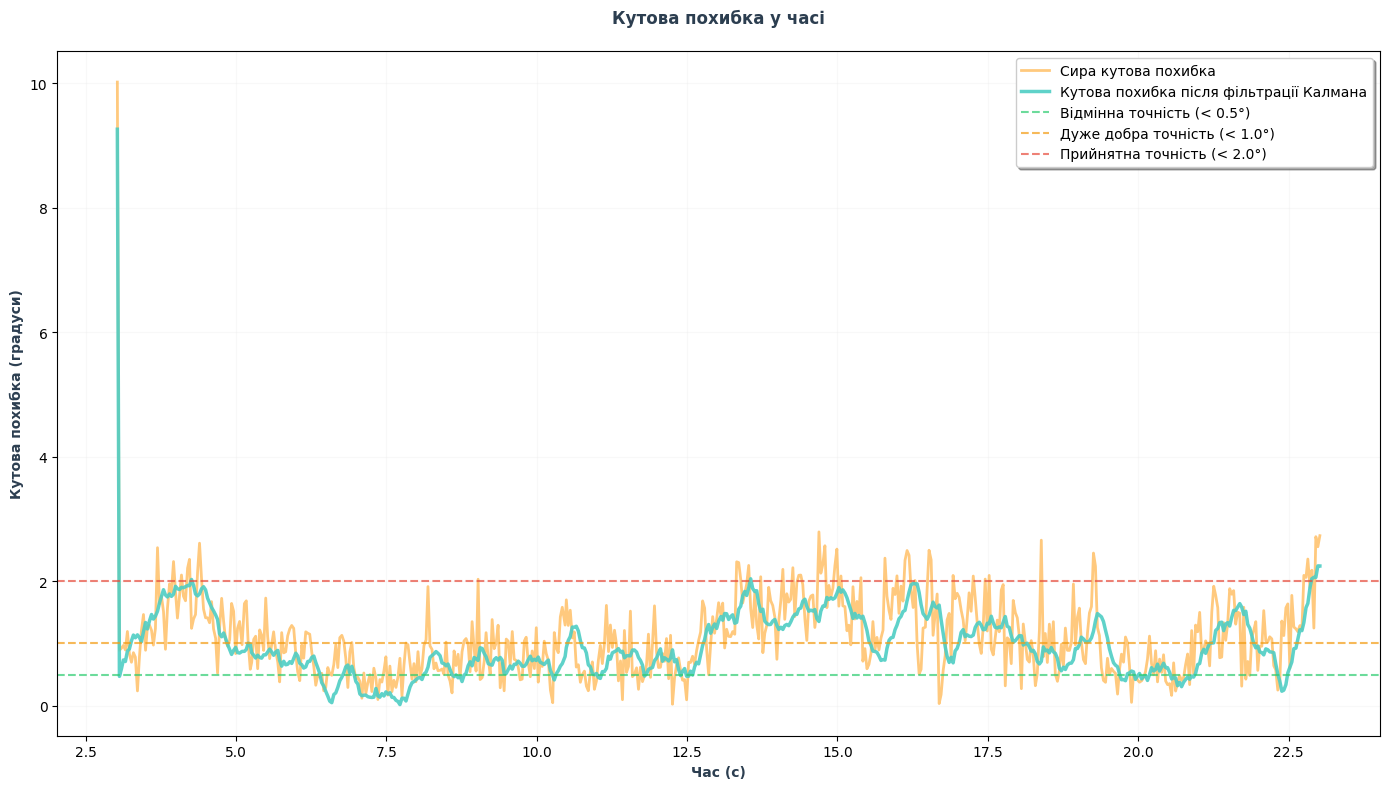

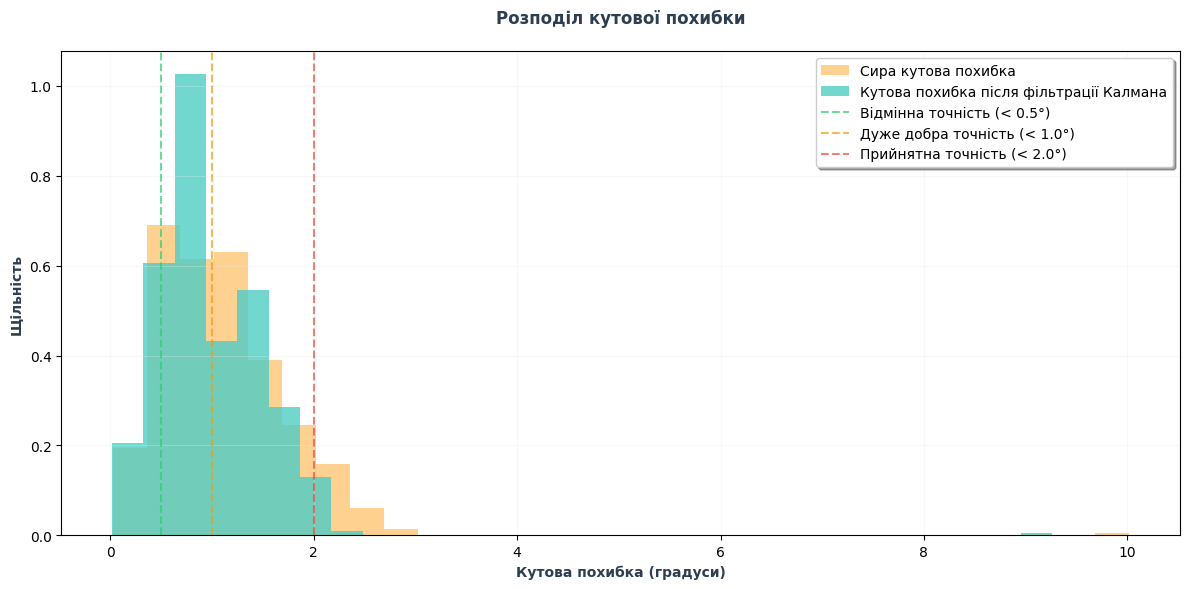

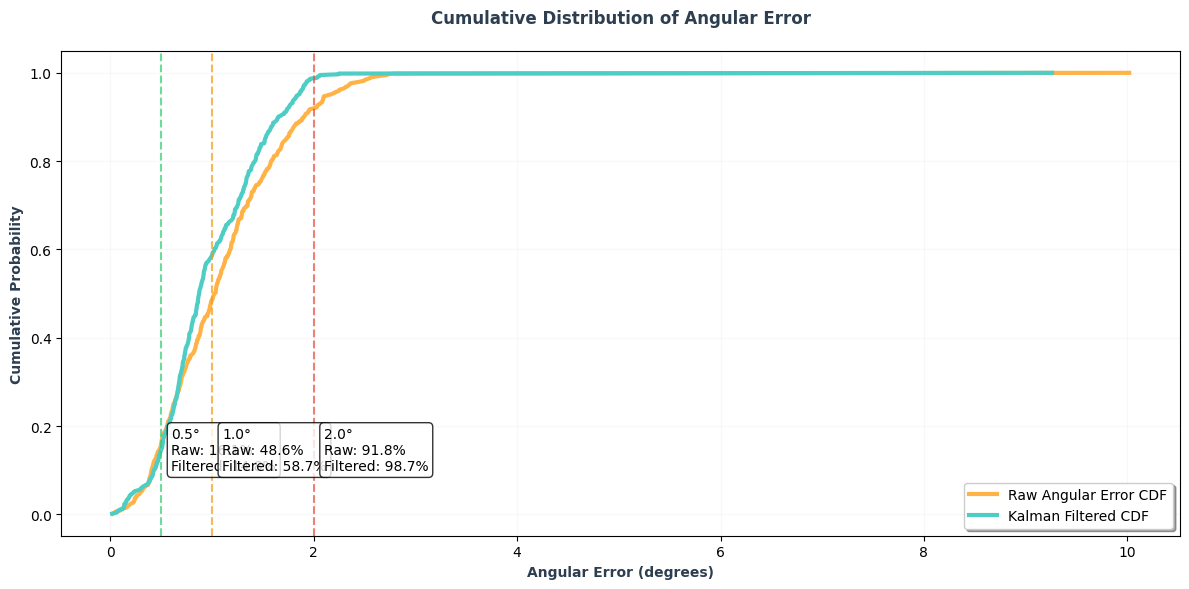

/var/folders/dj/stt1gbg10g9gv_cl5z5j81wc0000gn/T/ipykernel_69703/117644536.py:152: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, labels=box_labels, patch_artist=True)


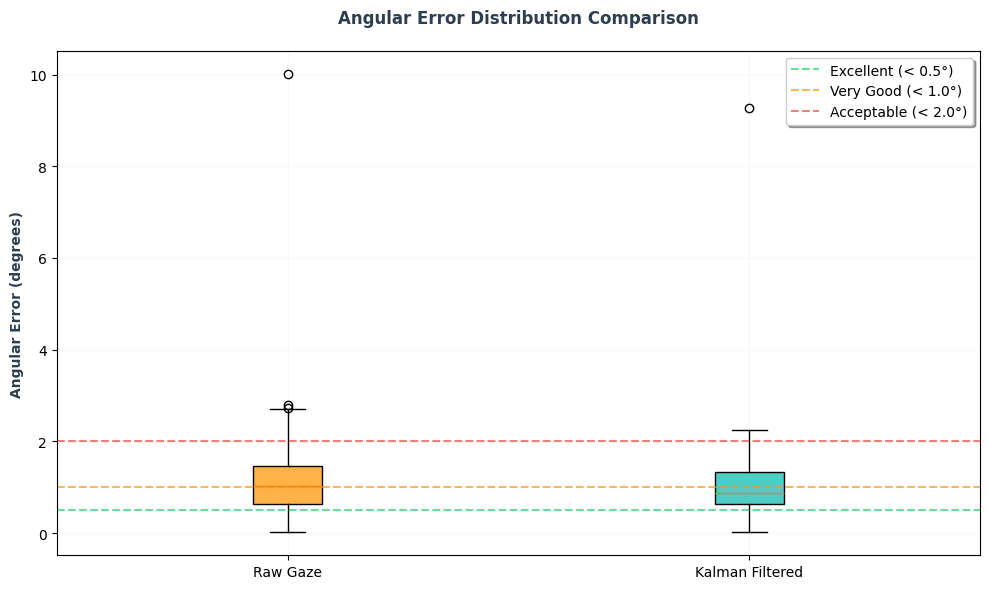

In [38]:
plot_angular_error_analysis(data, filename)

In [34]:
print_statistics(data, filename)


📊 STATISTICS FOR FILE: trajectory_test_1750019713.csv
📈 Total points: 601
📈 Valid points: 601

📏 PIXEL ERRORS:
📈 Average error (Raw): 66.10px
📈 Average error (Kalman): 59.23px
📈 Std deviation (Raw): 40.73px
📈 Std deviation (Kalman): 34.76px

🎯 ANGULAR ERRORS:
📈 Average error (Raw): 0.796°
📈 Average error (Kalman): 0.719°
📈 Std deviation (Raw): 0.487°
📈 Std deviation (Kalman): 0.419°

🎯 ANGULAR ERROR ANALYSIS
📊 Raw Gaze:
   Average: 0.80° (Very Good)
   Std Dev: 0.49°
   Quality: Commercial eye tracker quality

📊 Kalman Filtered:
   Average: 0.72° (Very Good)
   Std Dev: 0.42°
   Quality: Commercial eye tracker quality

🎯 Filter Performance:
   Accuracy improvement: 9.7%
   Precision improvement: 14.0%

📏 Industry Benchmarks:
   Research grade: < 0.5°
   Commercial grade: 0.5-1.0°
   Consumer grade: 1.0-2.0°
   Minimum usable: < 3.0°

🎯 FILTER IMPROVEMENTS:
Pixel accuracy: 10.4%
Angular accuracy: 9.7%
Smoothing effect: 27.2%
